In [7]:
import pandas as pd
import glob
import os

# Tìm tất cả file google_maps_reviews*.csv
files = glob.glob("google_maps_reviews*.csv")

all_data = []

for file_path in files:
    try:
        df = pd.read_csv(file_path)

        # Xóa dòng có text rỗng / null
        df = df.dropna(subset=["text"])
        df = df[df["text"].astype(str).str.strip() != ""]

        # Thêm tên file
        df["source_file"] = os.path.basename(file_path)

        print(f"✅ {file_path}: {len(df)} reviews hợp lệ")

        all_data.append(df)

    except Exception as e:
        print(f"❌ Lỗi {file_path}: {e}")

# Gộp tất cả dữ liệu
merged_df = pd.concat(all_data, ignore_index=True)

print("\n===== SAU KHI LỌC =====")
print(merged_df.head())

print(f"\nTổng số review hợp lệ: {len(merged_df)}")

# Lưu file mới
merged_df.to_csv("clean_google_maps_reviews.csv", index=False)

print("\n💾 Đã lưu: clean_google_maps_reviews.csv")

✅ google_maps_reviews_20260130_001008.csv: 940 reviews hợp lệ
✅ google_maps_reviews_20260130_132842.csv: 150 reviews hợp lệ
✅ google_maps_reviews_20260130_133200.csv: 379 reviews hợp lệ
✅ google_maps_reviews_20260224_185005.csv: 20 reviews hợp lệ
✅ google_maps_reviews_20260224_185216.csv: 378 reviews hợp lệ
✅ google_maps_reviews_20260224_191036.csv: 5916 reviews hợp lệ
✅ google_maps_reviews_20260224_213846.csv: 1991 reviews hợp lệ
✅ google_maps_reviews_20260513_233550.csv: 10441 reviews hợp lệ
✅ google_maps_reviews_20260514_020235.csv: 33706 reviews hợp lệ
✅ google_maps_reviews_20260514_132752.csv: 3607 reviews hợp lệ

===== SAU KHI LỌC =====
                                 place_name  \
0  Mr.Saigon - Mì Ý, Salad Sài Gòn - Lê Lai   
1  Mr.Saigon - Mì Ý, Salad Sài Gòn - Lê Lai   
2  Mr.Saigon - Mì Ý, Salad Sài Gòn - Lê Lai   
3  Mr.Saigon - Mì Ý, Salad Sài Gòn - Lê Lai   
4  Mr.Saigon - Mì Ý, Salad Sài Gòn - Lê Lai   

                                      user rating            time 

In [8]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("clean_google_maps_reviews.csv")

# Tính số lượng từ trong mỗi review
df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

# Lọc review ngắn theo số từ
# Ví dụ: dưới 5 từ
short_reviews = df[df["word_count"] < 2]

# Tổng số review ngắn
print(f"Tổng số review ngắn (<5 từ): {len(short_reviews)}")

# Thống kê phân phối word count
print("\n===== PHÂN PHỐI WORD COUNT =====")
print(df["word_count"].describe())

# Hiển thị ví dụ
print("\n===== REVIEW NGẮN =====")
print(short_reviews[["text", "word_count"]].head(20))

Tổng số review ngắn (<5 từ): 311

===== PHÂN PHỐI WORD COUNT =====
count    57528.000000
mean        26.751286
std         30.571857
min          1.000000
25%          9.000000
50%         18.000000
75%         36.000000
max        881.000000
Name: word_count, dtype: float64

===== REVIEW NGẮN =====
      text  word_count
611   Good           1
668     Ok           1
691     Ok           1
708     Ok           1
1030  ngon           1
1041   Ok.           1
1042    Ổn           1
1043    Lp           1
1045  Good           1
1048  Ngon           1
1049    Ok           1
1050  Ngon           1
1051  Ngon           1
1052  Ngon           1
1053  Good           1
1054    Ok           1
1055  Ngon           1
1056  Good           1
1057  Ngon           1
1058  Good           1


In [9]:
import pandas as pd
import re

# Đọc dữ liệu
df = pd.read_csv("clean_google_maps_reviews.csv")

# =========================
# CLEAN RATING
# =========================
# Ví dụ:
# "1 sao" -> 1
# "5 stars" -> 5

df["rating"] = (
    df["rating"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

# bỏ rating lỗi/null
df = df.dropna(subset=["rating"])

# =========================
# TEXT PREPROCESSING
# =========================
def preprocess_text(text):
    text = str(text)

    # lowercase
    text = text.lower()

    # bỏ url
    text = re.sub(r"http\S+|www\S+", "", text)

    # bỏ ký tự đặc biệt
    text = re.sub(r"[^\w\s]", " ", text)

    # bỏ số
    text = re.sub(r"\d+", "", text)

    # bỏ khoảng trắng thừa
    text = re.sub(r"\s+", " ", text).strip()

    return text

# preprocess
df["clean_text"] = df["text"].apply(preprocess_text)

# =========================
# WORD COUNT
# =========================
df["word_count"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

# =========================
# FILTER
# =========================
MIN_WORDS = 5
MAX_WORDS = 50

filtered_df = df[
    (df["word_count"] >= MIN_WORDS) &
    (df["word_count"] <= MAX_WORDS)
]

# =========================
# SORT RATING
# =========================
filtered_df = filtered_df.sort_values(
    by="rating",
    ascending=True
)

print(f"Tổng review ban đầu: {len(df)}")
print(f"Sau filtering: {len(filtered_df)}")

# =========================
# CHECK DISTRIBUTION
# =========================
print("\n===== RATING DISTRIBUTION =====")
print(filtered_df["rating"].value_counts().sort_index())

# =========================
# SAMPLE
# =========================
print("\n===== SAMPLE =====")

print(
    filtered_df[
        ["rating", "text", "clean_text", "word_count"]
    ].head(20)
)

# =========================
# SAVE
# =========================
filtered_df.to_csv(
    "preprocessed_filtered_reviews_sorted.csv",
    index=False
)

print("\n✅ Đã lưu: preprocessed_filtered_reviews_sorted.csv")

Tổng review ban đầu: 57495
Sau filtering: 43441

===== RATING DISTRIBUTION =====
rating
1.0     5491
2.0     2356
3.0     4879
4.0     9588
5.0    21127
Name: count, dtype: int64

===== SAMPLE =====
       rating                                               text  \
11140     1.0     Bún không ngon, chất lượng không như bảng hiệu   
40327     1.0  -Quán nhân viên phục vụ tệ, thái độ khi khách ...   
7625      1.0  chờ lâu mới có món, nhân viên sơ suất trong vc...   
40325     1.0  Order đậu + bún thêm nhân viên không mang ra.\...   
7623      1.0  nhân viên hơi ngộ, bàn sopha cho 4 người nhưng...   
32273     1.0  Giá cao hơn mặt bằng trung bình.Bò né mà dk mấ...   
32274     1.0        thịt trong món bún chả có lẽ nhiễm giun sán   
26569     1.0  Thái độ phục vụ cực kì tệ. Lúc trước quán này ...   
26568     1.0  Nhà mình mua 4 tô tối ăn, cả nhà mình bị đau b...   
26567     1.0  Nhân viên để thiếu đồ ăn cho khách. Khách hỏi ...   
26566     1.0                        Thái độ nhân viê

===== STAR DISTRIBUTION =====
rating
1.0     5491
2.0     2356
3.0     4879
4.0     9588
5.0    21127
Name: count, dtype: int64


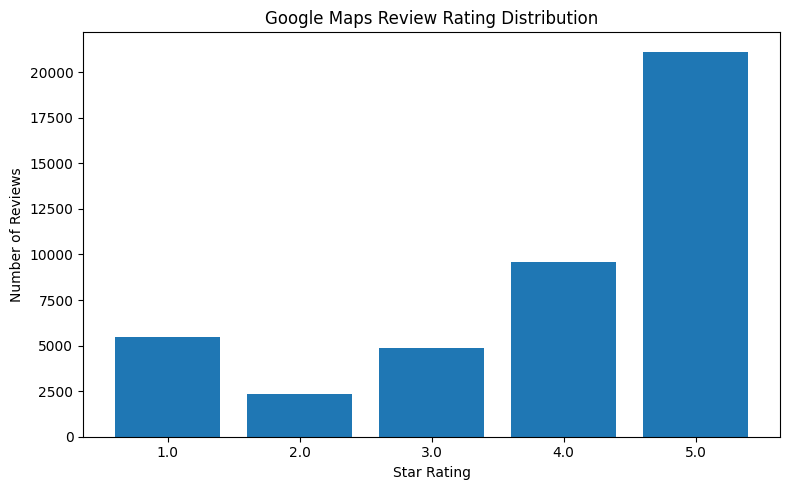


===== PERCENTAGE =====
rating
1.0    12.64
2.0     5.42
3.0    11.23
4.0    22.07
5.0    48.63
Name: count, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("preprocessed_filtered_reviews_sorted.csv")

# =========================
# PHÂN BỐ SỐ SAO
# =========================
star_counts = df["rating"].value_counts().sort_index()

print("===== STAR DISTRIBUTION =====")
print(star_counts)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 5))

plt.bar(
    star_counts.index.astype(str),
    star_counts.values
)

plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.title("Google Maps Review Rating Distribution")

plt.tight_layout()
plt.show()

# =========================
# PHẦN TRĂM
# =========================
print("\n===== PERCENTAGE =====")

percentages = (
    star_counts / len(df) * 100
).round(2)

print(percentages)

In [7]:
# 1. Count duplicates based ONLY on the text column
text_duplicate_count = df.duplicated(subset=['text']).sum()
print(f"Number of duplicate review texts: {text_duplicate_count}")

# 2. View all rows that share a duplicate text (including the first occurrence)
# We sort by 'review_text' so identical reviews appear next to each other
text_duplicates = df[df.duplicated(subset=['text'], keep=False)].sort_values(by='text')

print("--- Rows with Duplicate Review Text ---")
print(text_duplicates[['text']].head(20)) # Adjust columns as needed

Number of duplicate review texts: 636
--- Rows with Duplicate Review Text ---
                                                    text
11658  (+) Quán ở vị trí khá dễ tìm.\nTrang trí khá d...
10371  (+) Quán ở vị trí khá dễ tìm.\nTrang trí khá d...
27282  - Quán rộng, thoáng đãng.\n- Có chỗ giữ xe rộn...
27303  - Quán rộng, thoáng đãng.\n- Có chỗ giữ xe rộn...
19029  1 tô khá nhiều, đúng với số tiền. Tuy nhiên kh...
14565  1 tô khá nhiều, đúng với số tiền. Tuy nhiên kh...
33189  1 tô to khá nhiều topping như thịt cua, tôm, h...
36527  1 tô to khá nhiều topping như thịt cua, tôm, h...
33177  1 tô đầy đủ 55k như ảnh.\nBán từ 7h30 đến 20h\...
36541  1 tô đầy đủ 55k như ảnh.\nBán từ 7h30 đến 20h\...
35580  11 người ăn gần hết menu luôn. Món nào cũng ng...
32746  11 người ăn gần hết menu luôn. Món nào cũng ng...
32741  2 lần ghé ăn do gần căn hộ, đồ ăn ngon và nhân...
35564  2 lần ghé ăn do gần căn hộ, đồ ăn ngon và nhân...
33187  45k tô thập cẩm siêu toa, nhiều thịt, nhiều bá...
36550  45k

In [7]:
import pandas as pd

df = pd.read_csv("preprocessed_filtered_reviews_sorted.csv")

test = "Trái cây cắt để lên mặt bàn bàn như này thì có"

result = df[df["text"].str.contains(test, na=False, regex=False)]

print(result.index)

Index([3164], dtype='int64')


In [6]:
df = pd.read_csv("..\output_labeled\google_maps_reviews_labeled_20260514_191809.csv")
df.info()
df.tail(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3160 entries, 0 to 3159
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   place_name   3160 non-null   object 
 1   user         3160 non-null   object 
 2   rating       3160 non-null   float64
 3   time         3160 non-null   object 
 4   text         3160 non-null   object 
 5   source_file  3160 non-null   object 
 6   clean_text   3160 non-null   object 
 7   word_count   3160 non-null   int64  
 8   food         3160 non-null   int64  
 9   service      3160 non-null   int64  
 10  place        3160 non-null   int64  
 11  price        3160 non-null   int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 296.4+ KB


,place_name,user,rating,time,text,source_file,clean_text,word_count,food,service,place,price
3159,Quốc Dân Quán - Tiệm Bia Hơi Gò Vấp,Hoài Nhơn Phan,1.0,4 tuần trước,Trái cây cắt để lên mặt bàn bàn như này thì có...,google_maps_reviews_20260224_213846.csv,trái cây cắt để lên mặt bàn bàn như này thì có...,16,0,0,1,0
